In [55]:
import sys
from pathlib import Path

# Get project root
PROJECT_ROOT = Path().resolve().parent

# Add src directory
SRC_PATH = PROJECT_ROOT / "src"

sys.path.append(str(SRC_PATH))

print("Project Root:", PROJECT_ROOT)
print("SRC Path Added:", SRC_PATH)

Project Root: C:\Users\POOJA\OneDrive\Desktop\project
SRC Path Added: C:\Users\POOJA\OneDrive\Desktop\project\src


In [56]:
import pandas as pd

from data_loader import load_train_test_data
from preprocessing import preprocess_dataframe
from feature_extraction import extract_train_test_features
from model.model_training import run_compact_model_comparison

print("Imports successful")

Imports successful


In [57]:
train_df, test_df = load_train_test_data("../Dataset")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (1986, 2)
Test Shape: (497, 2)


,text,label
0,ENGINEERING CONSULTANT Professional Summary To...,CONSULTANT
1,CARPENTER Summary Carpenter Foreman Position w...,CONSTRUCTION
2,DIGITAL MARKETING SPECIALIST Summary Digital m...,DIGITAL-MEDIA
3,SOUS CHEF Work Experience Sous Chef Jul 2010 C...,CHEF
4,DONOR ADVOCATE Professional Summary Organized ...,ADVOCATE


In [58]:
train_processed = preprocess_dataframe(train_df)
test_processed = preprocess_dataframe(test_df)

train_processed.head()

,text,label
0,engin consult profession summari deliv valu pr...,CONSULTANT
1,carpent summari carpent foreman posit effect u...,CONSTRUCTION
2,digit market specialist summari digit market p...,DIGITAL-MEDIA
3,sou chef work experi sou chef jul compani ï¼​ ...,CHEF
4,donor advoc profession summari organ professio...,ADVOCATE


In [59]:
vectorizer, x_train, x_test = extract_train_test_features(
    train_processed,
    test_processed,
    text_column="text"
)

y_train = train_processed["label"]
y_test = test_processed["label"]

print("Feature Extraction Done")
print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

C:\Users\POOJA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(


Feature Extraction Done
Train Shape: (1986, 5000)
Test Shape: (497, 5000)


In [ ]:
results = run_compact_model_comparison(
    train_df=train_processed,
    test_df=test_processed
)

results.keys()

C:\Users\POOJA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(
C:\Users\POOJA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(
C:\Users\POOJA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(
C:\Users\POOJA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.p

dict_keys(['results_df', 'top_overall', 'randomforest_svm', 'best_combo'])

In [ ]:
results_df = results["results_df"]

results_df.head(10)

,model,accuracy,balanced_accuracy,precision,recall,f1_score,precision_weighted,recall_weighted,f1_weighted,train_time_sec,max_features,ngram_range,min_df,max_df,analyzer,stop_words
0,LinearSVM,0.726358,0.679253,0.697060,0.679253,0.664715,0.723929,0.726358,0.710904,1.2095,12000,"(1, 3)",2,0.90,word,english
1,RandomForest,0.722334,0.678233,0.712464,0.678233,0.658572,0.734209,0.722334,0.700384,7.6544,12000,"(1, 3)",2,0.90,word,english
2,RandomForest,0.716298,0.678973,0.708930,0.678973,0.662090,0.724280,0.716298,0.696984,13.3498,8000,"(1, 2)",2,0.95,word,english
3,RidgeClassifier,0.710262,0.674352,0.702397,0.674352,0.658460,0.719750,0.710262,0.693239,1.3099,8000,"(1, 2)",2,0.95,word,english
4,RidgeClassifier,0.710262,0.667536,0.691277,0.667536,0.651706,0.716097,0.710262,0.693897,1.1088,12000,"(1, 3)",2,0.90,word,english
5,LinearSVM,0.706237,0.660704,0.679828,0.660704,0.645614,0.704444,0.706237,0.690087,1.3557,8000,"(1, 2)",2,0.95,word,english
6,LogisticRegression,0.696177,0.654680,0.672442,0.654680,0.640365,0.696161,0.696177,0.681683,3.1109,12000,"(1, 3)",2,0.90,word,english
7,LogisticRegression,0.682093,0.638723,0.623404,0.638723,0.619616,0.672411,0.682093,0.665656,4.8168,8000,"(1, 2)",2,0.95,word,english


In [ ]:
results["top_overall"]

,model,accuracy,balanced_accuracy,f1_score,train_time_sec,ngram_range,analyzer
0,LinearSVM,0.726358,0.679253,0.664715,1.2095,"(1, 3)",word
1,RandomForest,0.722334,0.678233,0.658572,7.6544,"(1, 3)",word
2,RandomForest,0.716298,0.678973,0.662090,13.3498,"(1, 2)",word
3,RidgeClassifier,0.710262,0.674352,0.658460,1.3099,"(1, 2)",word
4,RidgeClassifier,0.710262,0.667536,0.651706,1.1088,"(1, 3)",word


In [ ]:
results["randomforest_svm"]

,model,accuracy,balanced_accuracy,f1_score,train_time_sec,ngram_range,analyzer
0,LinearSVM,0.726358,0.679253,0.664715,1.2095,"(1, 3)",word
1,RandomForest,0.722334,0.678233,0.658572,7.6544,"(1, 3)",word
2,RandomForest,0.716298,0.678973,0.662090,13.3498,"(1, 2)",word
5,LinearSVM,0.706237,0.660704,0.645614,1.3557,"(1, 2)",word


In [ ]:
best_combo = results["best_combo"]

best_combo

{'model': 'LinearSVM',
 'accuracy': np.float64(0.7263581488933601),
 'balanced_accuracy': np.float64(0.6792533179202179),
 'precision': np.float64(0.6970601418860775),
 'recall': np.float64(0.6792533179202179),
 'f1_score': np.float64(0.6647154126542134),
 'precision_weighted': np.float64(0.7239285806451528),
 'recall_weighted': np.float64(0.7263581488933601),
 'f1_weighted': np.float64(0.7109042488238011),
 'train_time_sec': np.float64(2.189),
 'max_features': np.int64(12000),
 'ngram_range': (1, 3),
 'min_df': np.int64(2),
 'max_df': np.float64(0.9),
 'analyzer': 'word',
 'stop_words': 'english'}

In [ ]:
from model_training import get_best_model

best_name, best_model, comparison_df = get_best_model(
    x_train,
    y_train,
    x_test,
    y_test
)

print("Best Model:", best_name)

comparison_df

Best Model: RandomForest


,model,accuracy,balanced_accuracy,precision,recall,f1_score,precision_weighted,recall_weighted,f1_weighted,train_time_sec
0,RandomForest,0.720322,0.674011,0.671983,0.674011,0.651542,0.722181,0.720322,0.699207,10.4084
1,RidgeClassifier,0.714286,0.685042,0.710053,0.685042,0.674909,0.725389,0.714286,0.700516,2.6419
2,LinearSVM,0.712274,0.674271,0.688653,0.674271,0.665129,0.712075,0.712274,0.699640,5.3786
3,LogisticRegression,0.682093,0.639157,0.660623,0.639157,0.627879,0.683075,0.682093,0.669936,2.6971


In [ ]:
predictions = best_model.predict(x_test)

predictions[:10]

array(['CONSTRUCTION', 'CONSTRUCTION', 'BANKING', 'BUSINESS-DEVELOPMENT',
       'HR', 'DIGITAL-MEDIA', 'DIGITAL-MEDIA', 'ACCOUNTANT', 'TEACHER',
       'FINANCE'], dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7203219315895373


In [ ]:
sample_results = pd.DataFrame({
    "Text": test_processed["text"].head(10),
    "Actual": y_test.head(10),
    "Predicted": predictions[:10]
})

sample_results

,Text,Actual,Predicted
0,owner fabric welder experi owner fabric welder...,CONSTRUCTION,CONSTRUCTION
1,sr estimatorba construct sale summari year pro...,CONSTRUCTION,CONSTRUCTION
2,vice presidentbusi bank sale manag healthcar s...,HEALTHCARE,BANKING
3,sale associ summari sale busi develop busi dev...,SALES,BUSINESS-DEVELOPMENT
4,hr manag highlight senior human resourc strate...,HR,HR
5,digit advertis oper intern skill custom suppor...,DIGITAL-MEDIA,DIGITAL-MEDIA
6,vice presid director client servic digit summa...,DIGITAL-MEDIA,DIGITAL-MEDIA
7,financ offic manag summari dedic financ manag ...,FINANCE,ACCOUNTANT
8,scienc teacher summari dedic teacher adept cha...,TEACHER,TEACHER
9,senior financ manag summari highli driven fina...,FINANCE,FINANCE


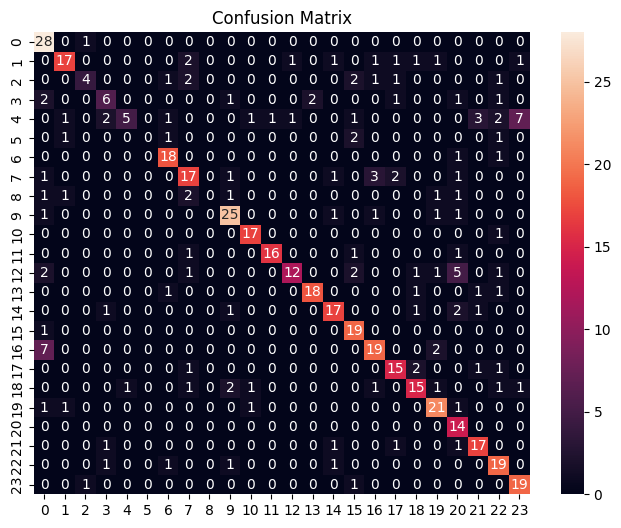

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.show()

In [ ]:
from feature_extraction import rank_resumes_by_job_description

job_description = "Looking for python machine learning engineer with NLP experience"

ranking = rank_resumes_by_job_description(
    job_description,
    test_processed["text"].tolist(),
    top_k=5
)

ranking

C:\Users\POOJA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(


,resume_index,similarity_score,resume_text
0,156,0.151988,softwar engin analyst skill program languag c ...
1,309,0.151270,highlight prog languag c yr python yr java yr ...
2,47,0.084368,engin intern skill c python matlab git bash r ...
3,188,0.062020,aviat record analyst summari highli organ deta...
4,454,0.057019,product design profession summari year engin e...
